# Cusanovich et al. (2018): clustering in t-SNE space, checked by CARVE

Source: Cusanovich et al., "A Single-Cell Atlas of In Vivo Mammalian Chromatin Accessibility." Cell 174.5 (2018): 1309-1324. GEO accession GSE111586.

sci-ATAC-seq of 81,173 nuclei from 13 adult mouse tissues. The source built an LSI (3 percent site filter, TF-IDF, 50-component SVD), ran t-SNE on it (Rtsne, perplexity 30, 5,000 iterations), and clustered the two-dimensional t-SNE with Seurat's graph community detection (Louvain) into 30 clusters.

Clustering a t-SNE can manufacture clusters: the embedding is stochastic and its islands depend on seed and perplexity. This notebook sweeps Louvain resolution, the source's own algorithm, under CARVE with randomized preprocessing (the LSI as-is, or a t-SNE of it at perplexity 30, 100 or 300) and asks which pipeline is stable and generalizable, and where the source's 30-cluster partition sits. The expectation, stated so it can be falsified: clustering in t-SNE space is less stable and less generalizable than clustering the LSI at the same granularity, and 30 clusters is past the point where either criterion starts to fall.

The reference is the source's own 30 clusters. Every comparison with it is reported as agreement, not accuracy.

---

## 0. Configuration

Everything below reads STUDIES["cusanovich"]: the scales, the resolution grid, the resample count and the preprocessing options. The fit needs the graph extra (igraph, for Louvain).

The study currently holds a preliminary atlas setting: 50 resamples (150 is the intended count), three quarters of them t-SNE (12 or 13 at each perplexity), and 15 Louvain configurations. Runtime at SCALE = "atlas", measured on an 11-core Mac with 18 GB on 2026-09-14: every t-SNE resample fits t-SNE on 50,164, 50,164 and 31,009 cells, 870 to 2,560 s per fit on one core between perplexity 30 and 300, and each configuration trains a random forest on 50,164 rows (40 s per resample). That totals about 62 core-hours, about 14 to 15 hours at N_JOBS = 5, plus an estimated half hour for the comparison section. N_JOBS stays at 5 because a perplexity-300 fit peaks near 3.4 GB, so eleven workers can exceed memory, and the six efficiency cores add little: five workers give 4.3 times one worker's throughput, eleven give 5.2. The fit is cached only once it completes, so keep the machine awake (caffeinate -i). SCALE = "dev" (1,500 cells) is for iteration; its perplexity comparisons do not carry over to the atlas, because in a 927-cell subsample most source clusters are smaller than perplexity 30.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt

from benchmarks._cusanovich_compare import (
    prepare_cusanovich_inputs,
    save_tables,
    selection_summary,
)
from benchmarks._preprocessing import resolve_preprocessing
from benchmarks._studies import (
    STUDIES,
    carve_cache_path,
    fit_or_load_carve,
    load_study,
    study_resolution_grids,
)
from benchmarks.figures import figure_cusanovich_results, figure_reference_scatter
from benchmarks.figures._cusanovich_results import MARKER_SIZE, SOURCE_TSNE_LABELS
from benchmarks.figures._paths import CASE_STUDY_DIR

RANDOM_SEED = 42
SCALE = "atlas"  # "dev", "publication" or "atlas"
N_JOBS = 5  # resample workers for the fit; the runtime note above gives the memory reason

# The selection every panel and table reads.
MEASURE = "stability"
RULE = "1se"
NOT_TWO = False

# Figures and tables are written under a scale-qualified directory, so
# development output can never be mistaken for the manuscript's. Only the
# publication directory is ever copied into overleaf/vis/.
OUT_DIR = CASE_STUDY_DIR if SCALE == "publication" else CASE_STUDY_DIR / SCALE
OUT_DIR.mkdir(parents=True, exist_ok=True)

study = STUDIES["cusanovich"]
model_grids = study_resolution_grids(study)
X, y, meta = load_study(study, scale=SCALE)
print(meta["n_cells"], "cells,", meta["n_features"], "LSI components,", meta["scale"], "scale")


def show(fig):
    """Display a figure exactly once, then close it."""
    display(fig)
    plt.close(fig)

81173 cells, 50 LSI components, atlas scale


---

## 1. The source's partition

The source's clusters on the source's own t-SNE (their Figure 1), restricted to the cells analyzed here. cell_metadata.txt ships both; the loader carries them as y and meta["source_tsne"], row for row with X. The subsample is stratified by cluster, so every cluster is present. Cells whose marker-based label is Unknown stay, because the 30 clusters assign them too.

30 source clusters; the smallest has 393 cells here
12.4% of the analyzed cells have cell_label Unknown (10029 of 81173 in the atlas)


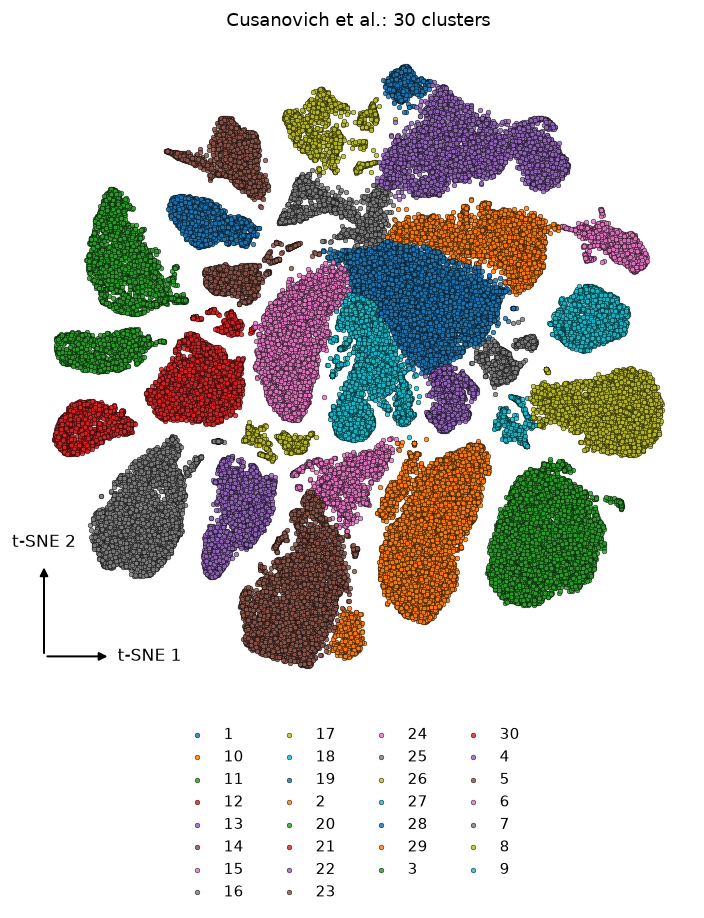

In [2]:
unknown = meta["source_labels"]["cell_label"] == "Unknown"
print(y.nunique(), "source clusters; the smallest has", y.value_counts().min(), "cells here")
print(
    f"{unknown.mean():.1%} of the analyzed cells have cell_label Unknown "
    f"({meta['n_cells_full'] - meta['n_cells_annotated']} of {meta['n_cells_full']} in the atlas)"
)

show(
    figure_reference_scatter(
        meta["source_tsne"], y.to_numpy(),
        axis_labels=SOURCE_TSNE_LABELS, title=f"Cusanovich et al.: {y.nunique()} clusters",
        marker_size=MARKER_SIZE, out_dir=OUT_DIR,
        save_name="cusanovich_reference_scatter.png",
    )
)

---

## 2. CARVE fit

Louvain over the study's resolution grid, with one preprocessing pipeline drawn per resample: the LSI as-is, or t-SNE at perplexity 30, 100 or 300 with the source's other settings (5,000 iterations, random initialization); 30 is the source's own perplexity. The LSI itself is computed once, on every cell, as the source computes it; only the second step is refit. Each pipeline is fit separately on each subsample, so an embedding that does not reproduce across fits lowers both criteria, and the generalizability classifier trains on the LSI itself. The cached fit's filename is keyed on the scale, the grid, the resample count and the preprocessing.

In [3]:
carve = fit_or_load_carve(
    X, y,
    cache_path=carve_cache_path(
        study, scale=SCALE, root=Path("./carve_state_saves"),
        model_grids=model_grids, n_resamples=study.n_resamples,
        preprocessing=study.preprocessing,
    ),
    model_grids=model_grids,
    n_resamples=study.n_resamples,
    randomize_preprocessing=True,
    **resolve_preprocessing(study.preprocessing),
    consensus_anchors=study.consensus_anchors,
    random_state=RANDOM_SEED,
    n_jobs=N_JOBS,
)
carve.estimator_results_[
    ["resolution", "n_clusters_observed", "ari_stability", "ari_generalizability"]
]

/Users/kaiwycik/GitHub/CARVE/code/src/benchmarks/_studies.py:336: RuntimeWarning: consensus_anchors=2000 opts this run in regardless of anchor_threshold, so CARVE is using anchored consensus over 2000 anchors. Per-sample scores and labels still cover every sample; consensus matrices and PAC are computed over the anchors.
  carve.fit(
/Users/kaiwycik/GitHub/CARVE/code/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,resolution,n_clusters_observed,ari_stability,ari_generalizability
0,0.020,13.34,0.900055,0.859034
1,0.029,14.16,0.852035,0.844352
2,0.041,15.00,0.809265,0.794666
3,0.059,16.24,0.814136,0.776424
4,0.084,17.48,0.827490,0.794523
5,0.120,18.60,0.853141,0.823308
6,0.170,20.50,0.855784,0.828400
7,0.240,22.84,0.815347,0.799235
8,0.350,25.82,0.817477,0.797789
9,0.500,30.86,0.756274,0.744881


CARVE's own plots of both criteria over the resolution grid: stability in the top row, generalizability in the bottom row. The left column pools every resample. Its dashed line is CARVE's selection under that row's criterion and RULE, so the bottom row marks the generalizability selection, not the MEASURE selection the rest of the notebook reads. The right column splits the same Louvain configuration by pipeline, each line over the resamples that pipeline received. Its dashed line marks the resolution RULE picks among all pipeline rows together, which can differ from the pooled selection. The two panels in a row share a y-axis, and resolution is drawn on a log axis to match the log-spaced grid.

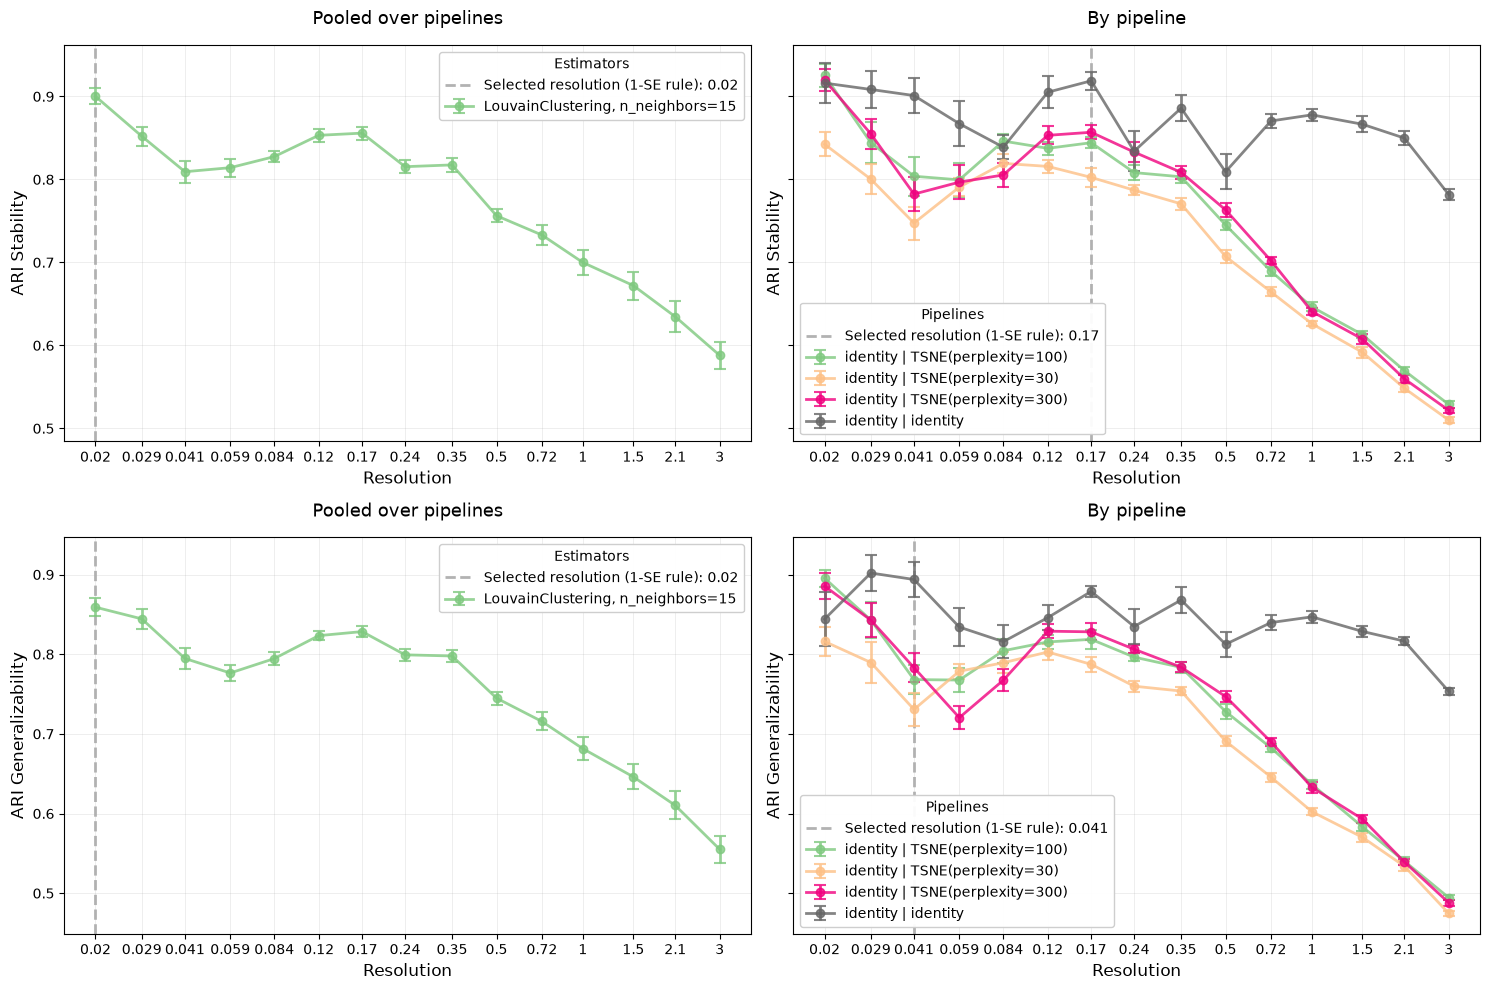

In [4]:
# Rows: stability, generalizability. Columns: pooled over pipelines, by pipeline.
# The resolution grid is log-spaced, so the axis is too.
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharey="row")
for row, measure in enumerate(["stability", "generalizability"]):
    carve.plot_metric_over_n_clusters(
        measure=measure, rule=RULE, not_two=NOT_TWO, ax=axes[row, 0],
        title="Pooled over pipelines",
    )
    carve.plot_metric_by_pipeline(
        measure=measure, rule=RULE, not_two=NOT_TWO, ax=axes[row, 1],
        title="By pipeline",
    )
for ax in axes.flat:
    ax.set_xscale("log")
    ax.set_xticks(study.resolutions, labels=[f"{r:g}" for r in study.resolutions])
    ax.minorticks_off()
show(fig)

---

## 3. Comparison

Three things set the source's recipe beside CARVE's: the pipeline CARVE rates best at its selected resolution; the source's operating point, the resolution at which clusterings of the t-SNE at the source's perplexity, 30, come nearest the source's cluster count; and the published partition's own generalizability under the classifier CARVE uses, on the same LSI.

In [5]:
inputs = prepare_cusanovich_inputs(
    X, y.to_numpy(), carve, source_tsne=meta["source_tsne"],
    measure=MEASURE, rule=RULE, not_two=NOT_TWO,
    random_state=RANDOM_SEED, n_jobs=-1,
)
selection_summary(inputs)

,quantity,value
0,measure,stability
1,rule,1se
2,not_two,False
3,n_cells,81173
4,source_clusters,30
5,selected_method,"LouvainClustering, n_neighbors=15"
6,selected_resolution,0.02
7,selected_n_clusters,13
8,selected_ari_stability,0.900055
9,selected_ari_generalizability,0.859034


In [6]:
table = carve.preprocessing_results_
table.loc[
    table["method_id"] == inputs.best_pipeline_row["method_id"],
    ["pipeline", "resolution", "n_resamples", "n_clusters_observed",
     "ari_stability", "ari_generalizability"],
]

,pipeline,resolution,n_resamples,n_clusters_observed,ari_stability,ari_generalizability
0,identity | TSNE(perplexity=100),0.020,12,15.416667,0.925572,0.895478
1,identity | TSNE(perplexity=100),0.029,12,16.500000,0.844201,0.842863
2,identity | TSNE(perplexity=100),0.041,12,17.166667,0.803851,0.768132
3,identity | TSNE(perplexity=100),0.059,12,18.333333,0.799453,0.767596
4,identity | TSNE(perplexity=100),0.084,12,19.416667,0.846209,0.804341
5,identity | TSNE(perplexity=100),0.120,12,19.833333,0.837465,0.815400
6,identity | TSNE(perplexity=100),0.170,12,22.083333,0.844251,0.818675
7,identity | TSNE(perplexity=100),0.240,12,24.583333,0.808237,0.796362
8,identity | TSNE(perplexity=100),0.350,12,28.416667,0.803158,0.783474
9,identity | TSNE(perplexity=100),0.500,12,33.916667,0.745114,0.728087


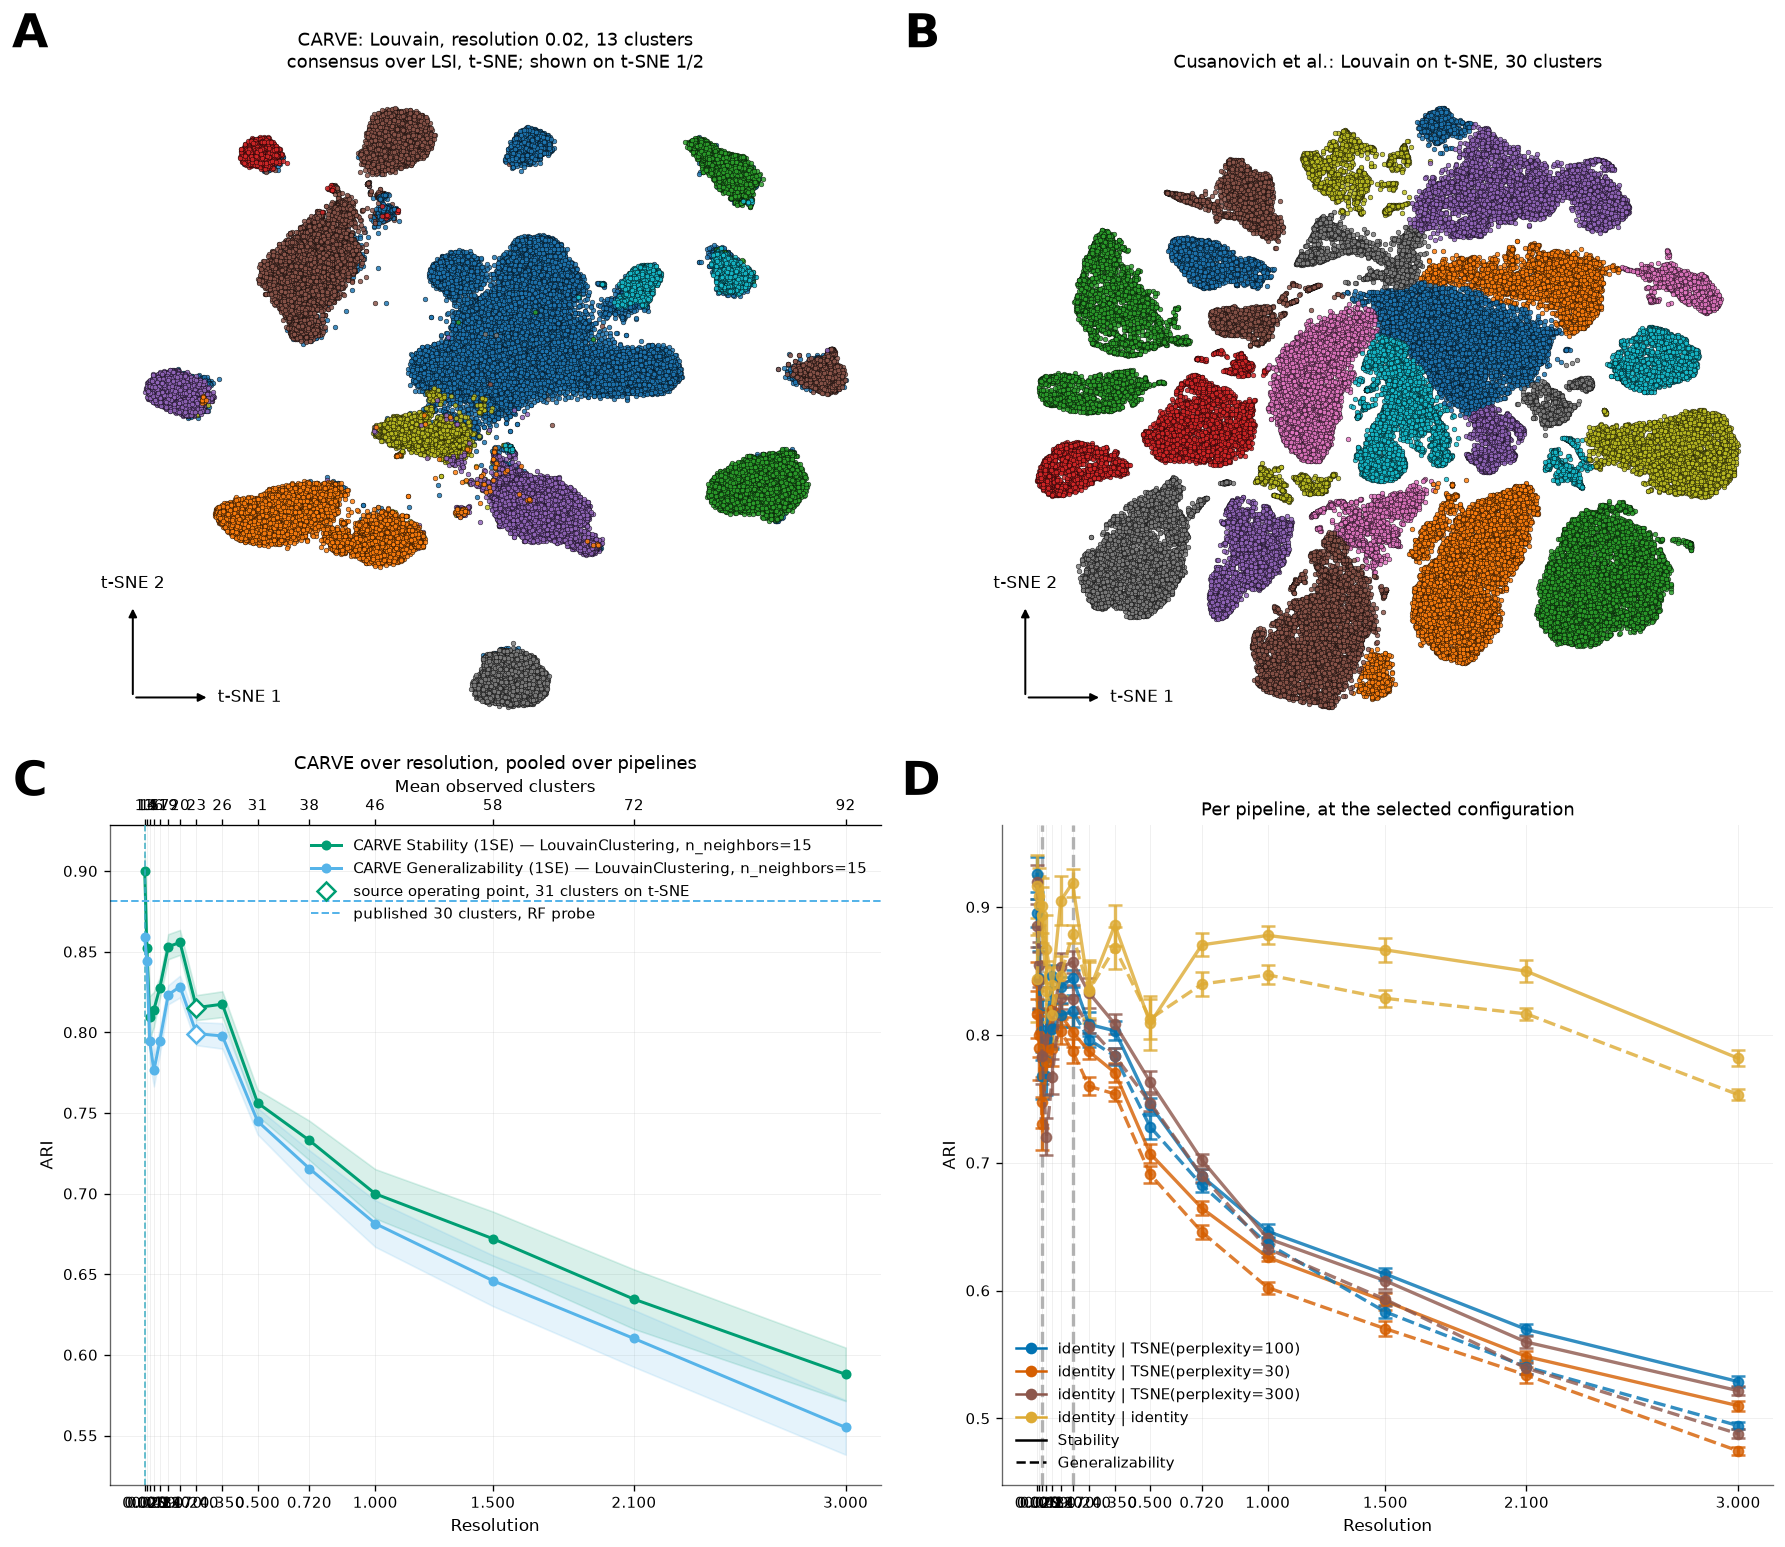

[PosixPath('/Users/kaiwycik/GitHub/CARVE/code/vis/case_studies/atlas/cusanovich_preprocessing_results.csv'),
 PosixPath('/Users/kaiwycik/GitHub/CARVE/code/vis/case_studies/atlas/cusanovich_selection_summary.csv')]

In [7]:
# The figure and both tables are written into OUT_DIR. Copying the
# publication figure into overleaf/vis/ stays a manual step.
show(figure_cusanovich_results(inputs, out_dir=OUT_DIR))
save_tables(inputs, OUT_DIR)

---

## 4. Summary

Panel C places the source's recipe on CARVE's pooled curves twice: at the resolution where the t-SNE pipeline reaches the source's cluster count, and as the published partition's generalizability under the same classifier probe. Panel D separates the curves by pipeline, which is where differences between clustering the LSI and clustering its t-SNE, and between perplexities, show. The selection summary, written to cusanovich_selection_summary.csv, holds every number the case study reports, including the agreement (ARI) between CARVE's consensus and the source's clusters; the per-pipeline table is written to cusanovich_preprocessing_results.csv.